In [1]:
initial_money = 1000
final_money = 1100

return_rate = (final_money - initial_money) / initial_money

print(f"收益率：{return_rate:.2%}")

收益率：10.00%


In [3]:
def calculate_return(initial_money, final_money):
    return (final_money - initial_money) / initial_money


result = calculate_return(1000, 1200)
print(f"收益率：{result:.2%}")

收益率：20.00%


In [5]:
def calculate_net_return(initial_money, final_money, total_cost=0):
    net_profit = final_money - initial_money - total_cost
    return net_profit / initial_money


result = calculate_net_return(
    initial_money=1000,
    final_money=1100,
    total_cost=10,
)

print(f"净收益率：{result:.2%}")

净收益率：9.00%


In [6]:
import pandas as pd

equity = pd.Series(
    [1000, 1100, 1050, 1300, 900, 1000],
    index=pd.date_range(
        "2026-01-01",
        periods=6,
        freq="1D",
        tz="UTC",
    ),
    name="equity",
)

In [12]:
# 计算每个时间点之前出现过的最高资金
historical_peak = equity.cummax()

In [11]:
# 计算当前资金相对历史最高点的回撤
drawdown = equity / historical_peak - 1

In [14]:
# 找到最严重的一次回撤
max_drawdown = drawdown.min()
trough_time = drawdown.idxmin()
peak_time = equity.loc[:trough_time].idxmax()

print(f"最大回撤：{max_drawdown:.2%}")
print(f"回撤高点：{peak_time}")
print(f"回撤低点：{trough_time}")

最大回撤：-30.77%
回撤高点：2026-01-04 00:00:00+00:00
回撤低点：2026-01-05 00:00:00+00:00


Matplotlib is building the font cache; this may take a moment.


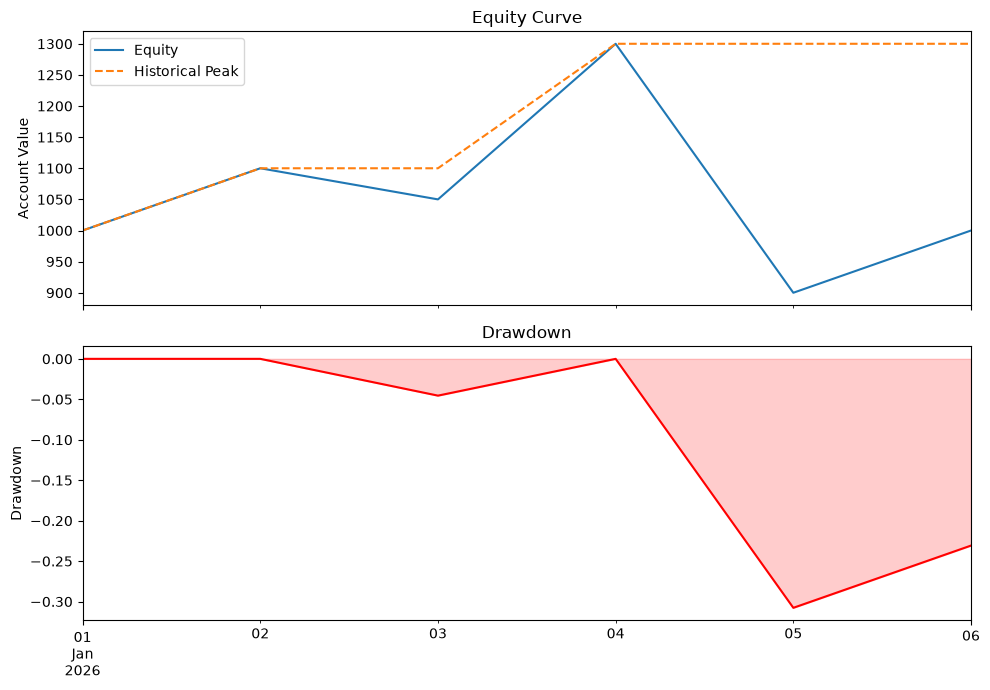

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

equity.plot(ax=axes[0], label="Equity")
historical_peak.plot(
    ax=axes[0],
    label="Historical Peak",
    linestyle="--",
)
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Account Value")
axes[0].legend()

drawdown.plot(ax=axes[1], color="red")
axes[1].fill_between(
    drawdown.index,
    drawdown.values,
    0,
    color="red",
    alpha=0.2,
)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")

plt.tight_layout()
plt.show()